In [2]:
import json
import pandas as pd
from tabulate import tabulate

# PARAMS_AND_TIMESTAMP = 'top_k_20_k_neighbors_15_n_tokens_0.2_MNT_300_test_size_0.2_reph_True_2025-10-09_12-34'
# FILE_PATH = F'/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/{MAX_TOKENS_AND_TIMESTAMP}/all_experiment_results.json'

param_to_test = 'n_tokens'
exps_files = { f'{param_to_test}_0.1': '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-11-16_04-34/top_k_20_k_neighbors_15_n_tokens_0.1_MNT_300_test_size_0.2_reph_False_2025-11-16_04-34/all_experiment_results.json',
                f'{param_to_test}_0.2': '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-11-16_04-34/top_k_20_k_neighbors_15_n_tokens_0.2_MNT_300_test_size_0.2_reph_False_2025-11-16_04-34/all_experiment_results.json',
                f'{param_to_test}_0.3': '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-11-16_04-34/top_k_20_k_neighbors_15_n_tokens_0.3_MNT_300_test_size_0.2_reph_False_2025-11-16_04-34/all_experiment_results.json',
                f'{param_to_test}_0.4': '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-11-16_04-35/top_k_20_k_neighbors_15_n_tokens_0.4_MNT_300_test_size_0.2_reph_False_2025-11-16_04-35/all_experiment_results.json',
                f'{param_to_test}_0.5': '/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-11-16_04-35/top_k_20_k_neighbors_15_n_tokens_0.5_MNT_300_test_size_0.2_reph_False_2025-11-16_04-35/all_experiment_results.json',
            }

FILE_PATH = exps_files[f'{param_to_test}_0.1']


# Load the JSON data
with open(
    FILE_PATH,
    'r') as f:
    data = json.load(f)

# Prepare a list to hold the table rows
table_data = []

for entry in data:
    model = entry['model_name']
    method = entry['method']
    binary_comparisons = entry['binary_comparisons']
    
    for rephrasing in entry['rephrasing_results']:
        rephrasing_method = rephrasing['neighbor_method']
        classifier = rephrasing['classifier']
        
        # Extract AUCs and at_1_fp from rephrasing_results
        retain_auc = rephrasing['Retain vs All AUC']
        forget_auc = rephrasing['Forget vs All AUC']
        holdout_auc = rephrasing['Holdout vs All AUC']
        multi_auc = rephrasing['Multi-class AUC']
        retain_at_1_fp = rephrasing['Retain_vs_All_auc_at_1_fp']
        forget_at_1_fp = rephrasing['Forget_vs_All_auc_at_1_fp']
        holdout_at_1_fp = rephrasing['Holdout_vs_All_auc_at_1_fp']
        
        # Extract Accuracy and F1 from binary_comparisons for holdout_vs_all (assuming this is the intended one for the table)
        accuracy = binary_comparisons['holdout_vs_all'][classifier]['accuracy']
        f1 = binary_comparisons['holdout_vs_all'][classifier]['f1']
        
        # Append the row with lowercase column names for consistency
        table_data.append({
            'model': model,
            'method': method,
            'rephrasing_method_(if exists)': rephrasing_method,
            'classifier': classifier,
            'retain_vs_all_auc': retain_auc,
            'forget_vs_all_auc': forget_auc,
            'holdout_vs_all_auc': holdout_auc,
            'multi_class_auc': multi_auc,
            'accuracy': accuracy,
            'f1': f1,
            'retain_vs_all_auc_at_1_fp': retain_at_1_fp,
            'forget_vs_all_auc_at_1_fp': forget_at_1_fp,
            'holdout_vs_all_auc_at_1_fp': holdout_at_1_fp
        })
        
        

# Create a DataFrame and display the table with borders
my_df = pd.DataFrame(table_data)
my_df.index = range(1, len(my_df) + 1)
my_df.index.name = '0'

In [3]:
# Final combined print for all sheets (TSV format for Google Sheets copy-paste)

import json
import pandas as pd
from tabulate import tabulate

# Reload and print the main my_df table
with open(
    FILE_PATH,
    'r') as f:
    data = json.load(f)

table_data = []
for entry in data:
    model = entry['model_name']
    method = entry['method']
    binary_comparisons = entry['binary_comparisons']
    
    for rephrasing in entry['rephrasing_results']:
        rephrasing_method = rephrasing['neighbor_method']
        classifier = rephrasing['classifier']
        
        retain_auc = rephrasing['Retain vs All AUC']
        forget_auc = rephrasing['Forget vs All AUC']
        holdout_auc = rephrasing['Holdout vs All AUC']
        multi_auc = rephrasing['Multi-class AUC']
        retain_at_1_fp = rephrasing['Retain_vs_All_auc_at_1_fp']
        forget_at_1_fp = rephrasing['Forget_vs_All_auc_at_1_fp']
        holdout_at_1_fp = rephrasing['Holdout_vs_All_auc_at_1_fp']
        
        accuracy = binary_comparisons['holdout_vs_all'][classifier]['accuracy']
        f1 = binary_comparisons['holdout_vs_all'][classifier]['f1']
        
        table_data.append({
            'model': model,
            'method': method,
            'rephrasing_method_(if exists)': rephrasing_method,
            'classifier': classifier,
            'retain_vs_all_auc': retain_auc,
            'forget_vs_all_auc': forget_auc,
            'holdout_vs_all_auc': holdout_auc,
            'multi_class_auc': multi_auc,
            'accuracy': accuracy,
            'f1': f1,
            'retain_vs_all_auc_at_1_fp': retain_at_1_fp,
            'forget_vs_all_auc_at_1_fp': forget_at_1_fp,
            'holdout_vs_all_auc_at_1_fp': holdout_at_1_fp
        })
        
my_df = pd.DataFrame(table_data)
my_df.index = range(1, len(my_df) + 1)
my_df.index.name = '0'

# Multiply by 100 and round to 3 decimals for relevant columns
auc_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp', 'accuracy', 'f1']
for col in auc_cols:
    if col in my_df.columns:
        my_df[col] = (my_df[col] * 100).round(3)

print(tabulate(my_df, headers='keys', tablefmt='tsv', showindex=True))

print("\n")

# Reload and print the theirs_df table
with open(
    FILE_PATH,
    'r') as f:
    data = json.load(f)

table_data = []

theirs_df = pd.DataFrame(table_data)
theirs_df.index = range(1, len(theirs_df) + 1)
theirs_df.index.name = '0'

# Multiply by 100 and round to 3 decimals for relevant columns
auc_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp']
for col in auc_cols:
    if col in theirs_df.columns:
        #check if numeric
        if theirs_df[col].dtype == 'float64' or theirs_df[col].dtype == 'int64':
            theirs_df[col] = (theirs_df[col] * 100).round(3)

print(tabulate(theirs_df, headers='keys', tablefmt='tsv', showindex=True))

print("\n\n")

# Define create_summary_table function (copied for self-containment)
def create_summary_table(df, group_by_column, metrics=['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp']):
    summary_df = df.groupby(group_by_column).agg({m: 'mean' for m in metrics}).reset_index()
    # Multiply by 100 and round to 3 decimals
    for col in metrics:
        # check if numeric
        if summary_df[col].dtype == 'float64' or summary_df[col].dtype == 'int64':
            summary_df[col] = (summary_df[col]).round(3)
    summary_df.index = range(1, len(summary_df) + 1)
    summary_df.index.name = '0'
    print(tabulate(summary_df, headers='keys', tablefmt='tsv', showindex=True))
    return summary_df

# Print summary by classifier
create_summary_table(my_df, 'classifier')
print("\n")

# Print summary by rephrasing_method_(if exists)
create_summary_table(my_df, 'rephrasing_method_(if exists)')
print("\n\n")


# Print summary by classifier and rephrasing_method_(if exists)
create_summary_table(my_df, ['classifier', 'rephrasing_method_(if exists)'])


  0	model                                           	method  	rephrasing_method_(if exists)  	classifier   	  retain_vs_all_auc	  forget_vs_all_auc	  holdout_vs_all_auc	  multi_class_auc	  accuracy	     f1	  retain_vs_all_auc_at_1_fp	  forget_vs_all_auc_at_1_fp	  holdout_vs_all_auc_at_1_fp
  1	LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8    	ELM     	token_embedding_proximity      	logistic     	             99.76 	             99.333	             100    	           99.872	   100    	100    	                     96.5  	                     93    	                     100
  2	LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8    	ELM     	token_embedding_proximity      	random_forest	             99.916	             99.854	             100    	           99.914	   100    	100    	                     97.5  	                     95.5  	                     100
  3	LLM-GAT/llama-3-8b-instruct-tar-checkpoint-8    	TAR     	token_embedding_proximity      	logistic     	             92.519	       

,classifier,rephrasing_method_(if exists),retain_vs_all_auc,forget_vs_all_auc,holdout_vs_all_auc,multi_class_auc,retain_vs_all_auc_at_1_fp,forget_vs_all_auc_at_1_fp,holdout_vs_all_auc_at_1_fp
0,,,,,,,,,
1,logistic,token_embedding_proximity,84.453,80.789,86.604,83.879,26.872,16.831,49.264
2,random_forest,token_embedding_proximity,85.507,83.202,90.643,85.981,27.291,26.894,58.833


In [4]:
# Aggregate results from all param_to_test experiments into a single DataFrame
import os
import re

all_results = []
for param_to_test_key, file_path in exps_files.items():
    if param_to_test == 'n_tokens':
        param_to_test_val = float(re.search(rf'{param_to_test}_(0\.\d+)', param_to_test_key).group(1))
    else:
        param_to_test_val = int(re.search(rf'{param_to_test}_(\d+)', param_to_test_key).group(1))
    with open(file_path, 'r') as f:
        data = json.load(f)
    for entry in data:
        model = entry['model_name']
        method = entry['method']
        binary_comparisons = entry['binary_comparisons']
        for rephrasing in entry['rephrasing_results']:
            rephrasing_method = rephrasing['neighbor_method']
            classifier = rephrasing['classifier']
            retain_auc = rephrasing['Retain vs All AUC']
            forget_auc = rephrasing['Forget vs All AUC']
            holdout_auc = rephrasing['Holdout vs All AUC']
            multi_auc = rephrasing['Multi-class AUC']
            retain_at_1_fp = rephrasing['Retain_vs_All_auc_at_1_fp']
            forget_at_1_fp = rephrasing['Forget_vs_All_auc_at_1_fp']
            holdout_at_1_fp = rephrasing['Holdout_vs_All_auc_at_1_fp']
            accuracy = binary_comparisons['holdout_vs_all'][classifier]['accuracy']
            f1 = binary_comparisons['holdout_vs_all'][classifier]['f1']
            all_results.append({
                f'{param_to_test}': param_to_test_val,
                'model': model,
                'method': method,
                'rephrasing_method': rephrasing_method,
                'classifier': classifier,
                'retain_vs_all_auc': retain_auc,
                'forget_vs_all_auc': forget_auc,
                'holdout_vs_all_auc': holdout_auc,
                'multi_class_auc': multi_auc,
                'accuracy': accuracy,
                'f1': f1,
                'retain_vs_all_auc_at_1_fp': retain_at_1_fp,
                'forget_vs_all_auc_at_1_fp': forget_at_1_fp,
                'holdout_vs_all_auc_at_1_fp': holdout_at_1_fp
            })

all_results_df = pd.DataFrame(all_results)
# Optionally, multiply metrics by 100 for readability
metric_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc',
               'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp', 'accuracy', 'f1']
for col in metric_cols:
    if col in all_results_df.columns:
        all_results_df[col] = all_results_df[col] * 100

# all_results_df.head()

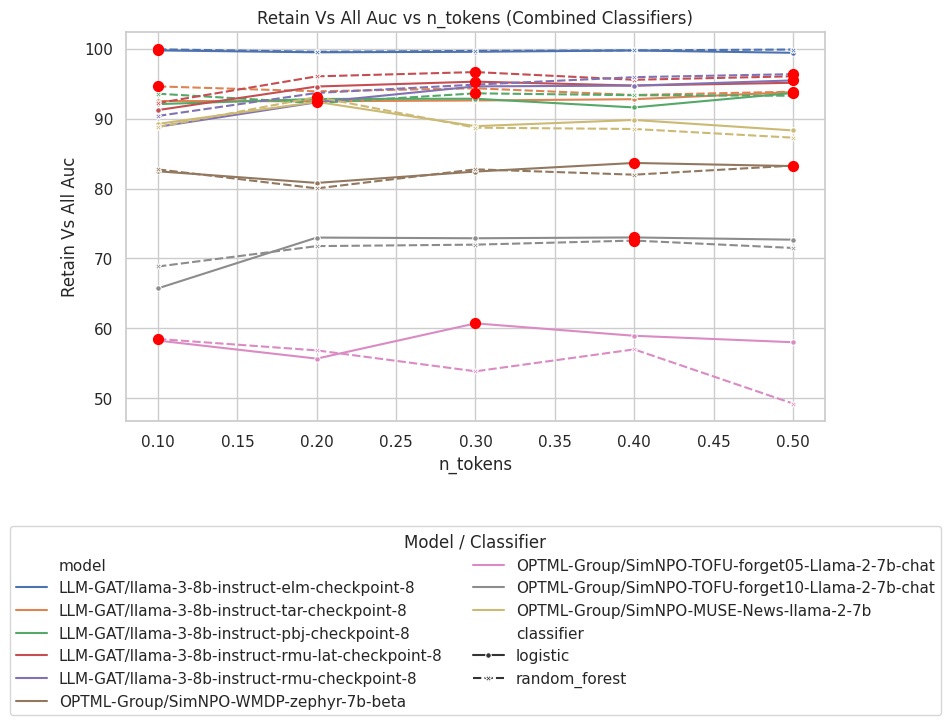

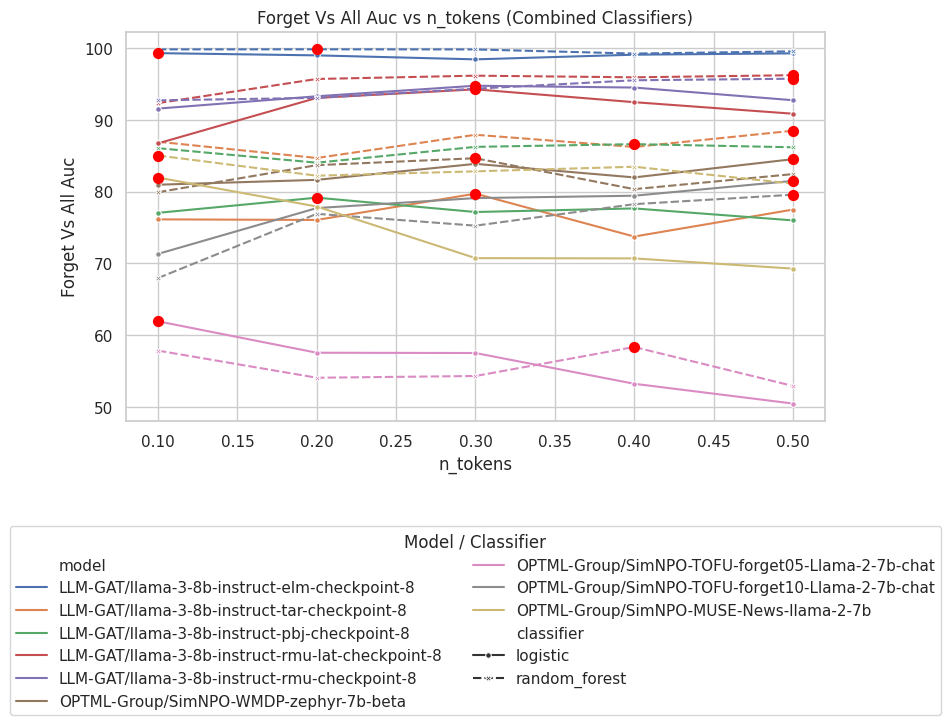

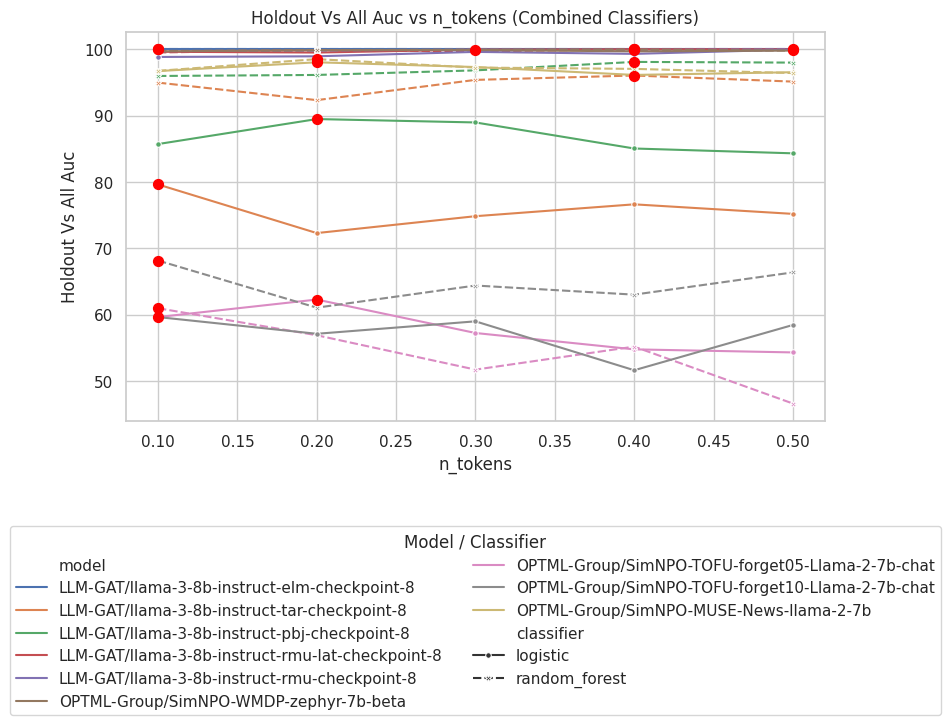

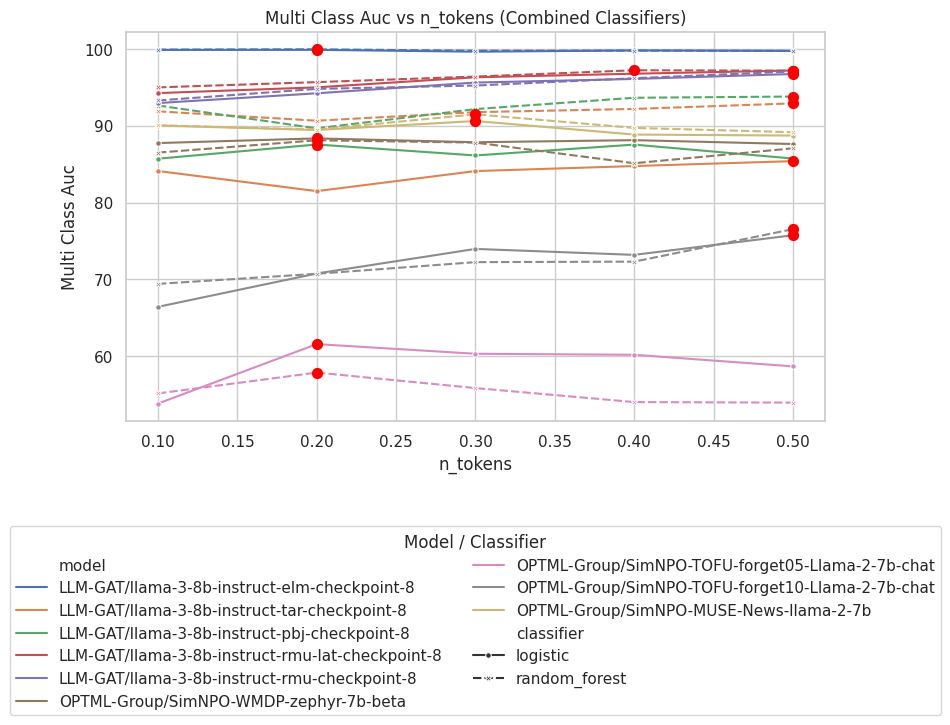

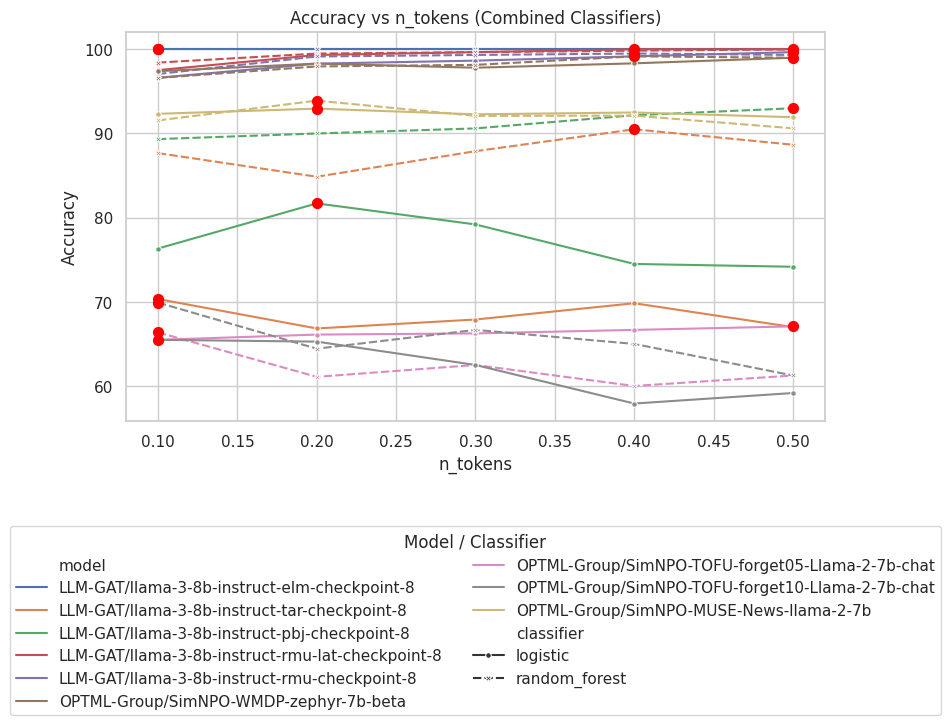

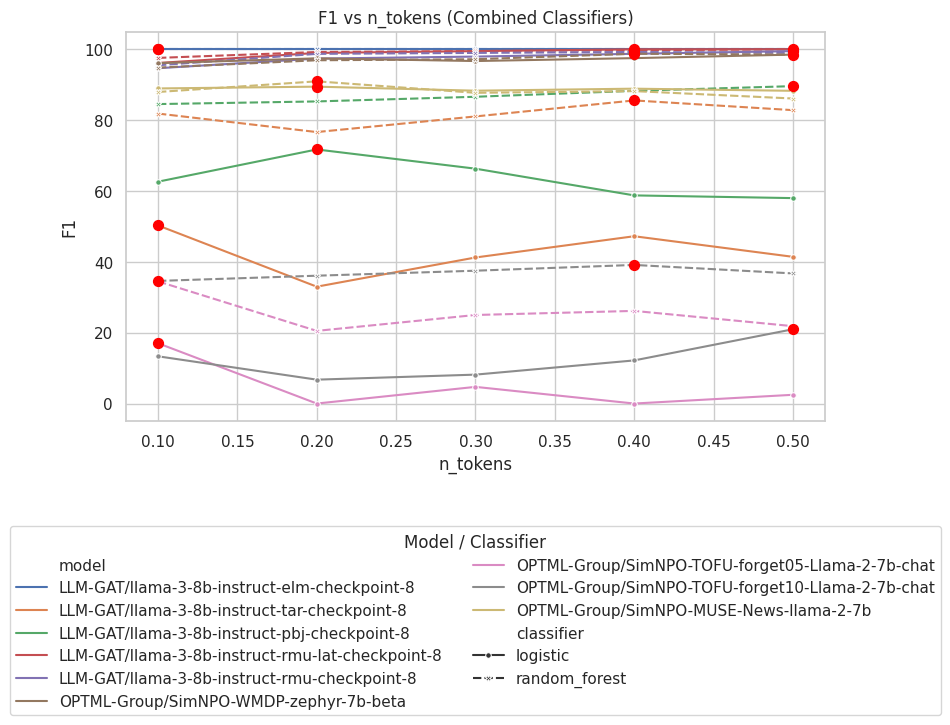

In [5]:
def plot_metrics_vs_param(all_results_df, param_to_test, metrics_to_plot, classifiers, separate_classifiers=False):
    """
    Plot how metrics change as a function of param_to_test, with lines for each model, separated by classifier or combined.

    Parameters:
    - all_results_df: DataFrame containing the aggregated results.
    - param_to_test: String, the parameter name (e.g., 'n_tokens').
    - metrics_to_plot: List of strings, metrics to plot (e.g., ['retain_vs_all_auc', ...]).
    - classifiers: List of strings, classifier types (e.g., ['logistic', 'random_forest']).
    - separate_classifiers: Boolean, True for separate plots per classifier, False for combined plot.
    """
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style='whitegrid')

    if separate_classifiers:
        for classifier in classifiers:
            filtered_df = all_results_df[all_results_df['classifier'] == classifier]
            linestyle = '--' if classifier == 'random_forest' else '-'
            for metric in metrics_to_plot:
                plt.figure(figsize=(8,5))
                sns.lineplot(
                    data=filtered_df,
                    x=f'{param_to_test}',
                    y=metric,
                    hue='model',
                    marker='o',
                    markersize=4,  # small markers on the line
                    linestyle=linestyle
                )
                # Overlay the highest point for each model in red and larger
                for model in filtered_df['model'].unique():
                    model_df = filtered_df[filtered_df['model'] == model]
                    max_idx = model_df[metric].idxmax()
                    max_row = model_df.loc[max_idx]
                    plt.scatter(max_row[f'{param_to_test}'], max_row[metric], color='red', s=50, zorder=5)
                plt.title(f'{metric.replace("_", " ").title()} vs {param_to_test} ({classifier})')
                plt.ylabel(metric.replace('_', ' ').title())
                plt.xlabel(f'{param_to_test}')
                plt.tight_layout()
                # Place legend below the plot
                plt.legend(title='Model', bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2)
                plt.show()
    else:
        # Combined plot for both classifiers
        for metric in metrics_to_plot:
            plt.figure(figsize=(8,5))
            sns.lineplot(
                data=all_results_df,
                x=f'{param_to_test}',
                y=metric,
                hue='model',
                style='classifier',  # Differentiate classifiers by line style/marker
                markers=True,
                markersize=4,
            )
            # Overlay the highest point for each model and classifier in red and larger
            for model in all_results_df['model'].unique():
                for classifier in classifiers:
                    model_class_df = all_results_df[(all_results_df['model'] == model) & (all_results_df['classifier'] == classifier)]
                    if not model_class_df.empty:
                        max_idx = model_class_df[metric].idxmax()
                        max_row = model_class_df.loc[max_idx]
                        plt.scatter(max_row[f'{param_to_test}'], max_row[metric], color='red', s=50, zorder=5)
            plt.title(f'{metric.replace("_", " ").title()} vs {param_to_test} (Combined Classifiers)')
            plt.ylabel(metric.replace('_', ' ').title())
            plt.xlabel(f'{param_to_test}')
            plt.tight_layout()
            # Place legend below the plot (now includes both hue and style)
            plt.legend(title='Model / Classifier', bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2)
            plt.show()

# Example usage (replace with your actual call)
plot_metrics_vs_param(
    all_results_df=all_results_df,
    param_to_test=param_to_test,
    metrics_to_plot=['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'accuracy', 'f1'],
    classifiers=['logistic', 'random_forest'],
    separate_classifiers=False  # Set to True for separate plots
)